In [29]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import plotly.graph_objects as go


Text(0, 0.5, 'Количество наблюдений')

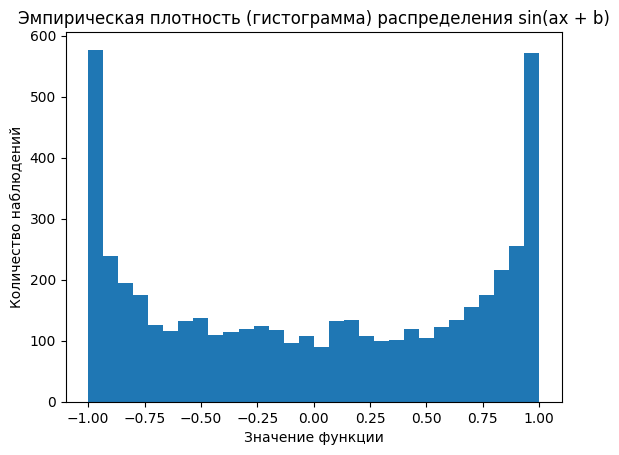

In [126]:
input_data = np.random.uniform(low=-1, high=1, size=5000)
a, b = (2*np.pi/2 , 2)
activation = np.sin(a*input_data + b)
plt.hist(activation, bins=30)
plt.title("Эмпирическая плотность (гистограмма) распределения sin(ax + b)")
plt.xlabel('Значение функции')
plt.ylabel('Количество наблюдений')

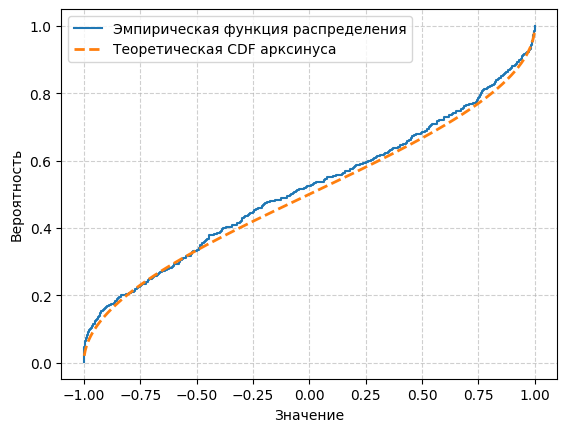

In [118]:
x = np.sort(activation)

y = np.arange(1, len(activation) + 1) / len(activation)
plt.step(x, y, where='post', label='Эмпирическая функция распределения')

x_theor = np.linspace(-1, 1, 1000)
x_theor = x_theor[(x_theor > -1) & (x_theor < 1)]

y_theor = 1/2 + (1/np.pi) * np.arcsin(x_theor)

plt.plot(x_theor, y_theor, '--', label='Теоретическая CDF арксинуса', linewidth=2)

# plt.title('Эмпирическая функция распределения (ECDF)')
plt.xlabel('Значение')
plt.ylabel('Вероятность')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Показать график
plt.show()

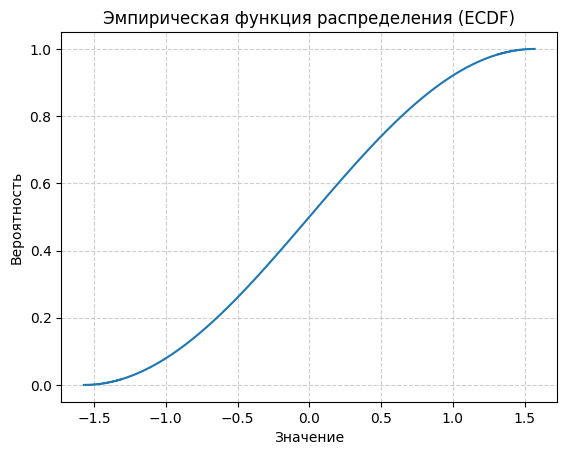

In [92]:
arcsine_arg = np.linspace(-1, 1, 10000)
arcsine = np.arcsin(arcsine_arg)
# plt.hist(input_data)
# plt.hist(arcsine, bins=50)

x = np.sort(arcsine)

# 2. Строим значения Y от 0 до 1 с равномерным шагом
y = np.arange(1, len(arcsine) + 1) / len(arcsine)

# 3. Рисуем ступенчатый график (plt.step или plt.plot с параметром 'drawstyle')
plt.step(x, y, where='post') # 'post' означает, что ступенька идет после точки

# Оформление (опционально)
plt.title('Эмпирическая функция распределения (ECDF)')
plt.xlabel('Значение')
plt.ylabel('Вероятность')
plt.grid(True, linestyle='--', alpha=0.6)

# Показать график
plt.show()

(array([ 590.,  473.,  502.,  487.,  509.,  522.,  556., 1223., 1558.,
        3580.]),
 array([-0.53963941, -0.38567547, -0.23171152, -0.07774758,  0.07621636,
         0.2301803 ,  0.38414424,  0.53810818,  0.69207212,  0.84603606,
         1.        ]),
 <BarContainer object of 10 artists>)

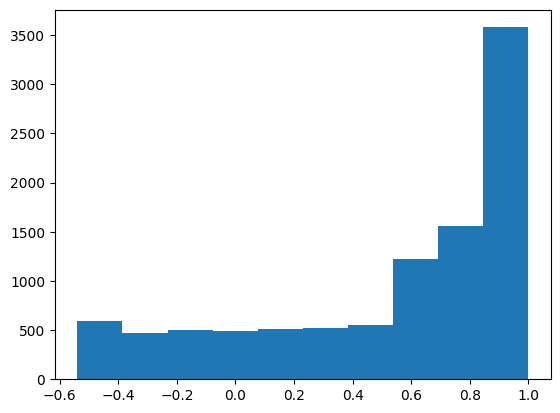

In [36]:
plt.hist(activation)

In [18]:
A = np.array([
    [1, 2, 3],
    [2, 1, 4],
    [5,5,5],
    [5, -3, 1],
    [10,1, 3],
    [3, 3, 2],
    [4, 2, 1],
    [2, 4, 3]
])

A_centered = A - np.mean(A, axis=0)

AtA = np.matmul(A_centered.T, A_centered)

eigenvalues, eigenvectors = np.linalg.eigh(AtA)

idx = np.argmin(eigenvalues)

min_eigenvalue = eigenvalues[idx]
min_eigenvector = eigenvectors[:, idx]

print("Минимальное собственное значение:", min_eigenvalue)
print("Соответствующий собственный вектор:", min_eigenvector)

normal = min_eigenvector

point_on_plane = np.array([0, 0, 0])

a, b, c = normal
d = -point_on_plane.dot(normal)

x = np.linspace(-5, 5, 20)
y = np.linspace(-5, 5, 20)

xx, yy = np.meshgrid(x, y)

zz = (-a * xx - b * yy - d) / c

points_plot = go.Scatter3d(
    x=A_centered[:,0],
    y=A_centered[:,1],
    z=A_centered[:,2],
    mode='markers',
    marker=dict(size=5)
)

plane = go.Surface(
    x=xx,
    y=yy,
    z=zz,
    opacity=0.5,
    showscale=False
)


normal_arrow = go.Cone(
    x=[point_on_plane[0]],
    y=[point_on_plane[1]],
    z=[point_on_plane[2]],
    u=[normal[0]],
    v=[normal[1]],
    w=[normal[2]],
    sizemode="absolute",
    sizeref=1
)


fig = go.Figure(data=[points_plot, plane, normal_arrow])

fig.update_layout(
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z"
    )
)

fig.show()

Минимальное собственное значение: 7.547762689479499
Соответствующий собственный вектор: [-0.07210557 -0.40064261  0.91339273]


In [26]:

A = np.array([
    [8, 2, 3],
    [1, 4, 4],
    [5,5,5],
    [5,-3,1],
    [3,5,2],
    [4,2,1],
])

center = A.mean(axis=0)

A_centered = A - center


AtA = A_centered.T @ A_centered
# AtA = A_centered @ A_centered.T


eigenvalues, eigenvectors = np.linalg.eigh(AtA)

idx = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print('СВ и СЗ матрицы A:')
for i in range(eigenvectors.shape[1]):
    print(f"СВ: {eigenvectors[:,i]}; СЗ: {eigenvalues[i]}")

pc1 = eigenvectors[:,0]
pc2 = eigenvectors[:,1]
normal = eigenvectors[:,2]


scale = 6

u = np.linspace(-scale, scale, 10)
v = np.linspace(-scale, scale, 10)

uu, vv = np.meshgrid(u, v)

plane_points = center + uu[...,None]*pc1 + vv[...,None]*pc2

xx = plane_points[:,:,0]
yy = plane_points[:,:,1]
zz = plane_points[:,:,2]

plane = go.Surface(
    x=xx,
    y=yy,
    z=zz,
    opacity=0.4,
    showscale=False
)

points = go.Scatter3d(
    x=A[:,0],
    y=A[:,1],
    z=A[:,2],
    mode='markers',
    marker=dict(size=5)
)

def arrow(origin, vec, length, color):

    vec = vec / np.linalg.norm(vec) * length
    end = origin + vec

    return go.Scatter3d(
        x=[origin[0], end[0]],
        y=[origin[1], end[1]],
        z=[origin[2], end[2]],
        mode="lines+markers",
        line=dict(color=color, width=6),
        marker=dict(size=4, color=color)
    )

scale = 1

arrows = []

arrows.append(arrow(center, pc1, scale*np.sqrt(eigenvalues[0]), "green"))
arrows.append(arrow(center, pc2, scale*np.sqrt(eigenvalues[1]), "green"))
arrows.append(arrow(center, normal, scale*np.sqrt(eigenvalues[2]), "red"))


fig = go.Figure(
    data=[points, plane] + arrows
)

fig.update_layout(
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z"
    )
)

fig.show()

СВ и СЗ матрицы A:
СВ: [-0.36953799  0.86807428  0.33149468]; СЗ: 56.71836115277378
СВ: [0.91166418 0.269692   0.31005587]; СЗ: 23.32998228605577
СВ: [-0.17975006 -0.41678925  0.89105367]; СЗ: 6.118323227837125


In [27]:
np.sum([eigenvectors[2][i]**2 for i in range(eigenvectors.shape[1])])

1.0

In [28]:
for i, eigenvector in enumerate(eigenvectors.T):
    sum_of_distances = sum([np.dot(vector, eigenvector)**2 for vector in A_centered])
    print(f"for eigenvector {eigenvector} withg eigenvalue {eigenvalues[i]} sum of distances = {sum_of_distances}")

for eigenvector [-0.36953799  0.86807428  0.33149468] withg eigenvalue 56.71836115277378 sum of distances = 56.718361152773795
for eigenvector [0.91166418 0.269692   0.31005587] withg eigenvalue 23.32998228605577 sum of distances = 23.329982286055767
for eigenvector [-0.17975006 -0.41678925  0.89105367] withg eigenvalue 6.118323227837125 sum of distances = 6.118323227837124


In [12]:
eigenvectors.shape[1]

3

In [22]:
eigenvectors

array([[-0.4487074 ,  0.87674025, -0.17317102],
       [ 0.83964114,  0.34722628, -0.41765616],
       [ 0.30604643,  0.33280692,  0.89195019]])